# Missing Hospital Appointments
Business intelligence and Data mining UFCFMM-30-3

By Jessica Hislop (23025306), Jasper Cordero (23016270), Momina Amin (22029761) and Zayar Lin

# Business problem: 
Why are patients missing appointments, and how can hospitals reduce no-shows?

## Importance of this problem:  

Missing hospital appointments have a significant impact on healthcare services quality. They can lead to inefficient resource allocation, lost revenue, and increased waiting times. Furthermore, it may delay diagnosis and treatment plans which negatively affects patient outcomes. It is important for hospitals to understand why patients fail to attend their appointments and develop strategies to reduce no-show rates and improve patient care. 

## Dataset:
The dataset we chose is a hospital appointment no-show prediction dataset.

## Dataset Justification:
The hospital appointment prediction dataset from Kaggle is suitable for our project because it directly aligns with the key business problem of why patients miss their appointments. The dataset includes a mix of demographic and appointment-related variables, which provides depth to explore patterns and factors that may influence patients' choices. Since the target variable is binary, it allows for classification and logistic regression models to compare different approaches effectively.   

Furthermore, the dataset is synthetic, meaning that it avoids ethical and legal risks that may be associated with real patient data. Therefore, this aligns with GDPR principles and ensures no real information is exposed. Furthermore, it also supports thorough machine learning analysis, allowing us to identify key patterns behind no-shows and build a predictive model that can help healthcare providers to reduce missed appointments,  improve resource allocation and enhance operational efficiency.   


# Understanding the dataset

It is important to fully understand the dataset before analysis to ensure it is of high quality, detect areas that need to be fixed, and to identify appropriate analysis and exploration methods (Medium, 2023). 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pandas.api.types import CategoricalDtype

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.cluster import KMeans

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    silhouette_score
)

df = pd.read_csv("hospital_appointment_no_show_5000 3.csv")
df.head()
#Preview of the dataset to check it has loaded correctly

,patient_id,age,gender,city_type,distance_km,travel_time_min,appointment_day,appointment_time_slot,department,waiting_days,...,chronic_disease,sms_reminder,email_reminder,num_reminders,employment_status,education_level,insurance_status,rainy_day,public_holiday,no_show
0,1,47.0,Female,Suburban,16.5,77.3,Sat,Evening,Pediatrics,8,...,0,1,0.0,1,NaN,Higher,Uninsured,1,0,1
1,2,37.0,Male,Suburban,6.7,26.9,Tue,Morning,Cardiology,8,...,1,1,0.0,2,Employed,Secondary,Insured,0,1,0
2,3,49.0,Female,Rural,8.2,46.1,Sat,Evening,General Medicine,3,...,0,1,0.0,1,Unemployed,Secondary,Insured,0,0,1
3,4,62.0,Female,Urban,2.6,15.2,Thu,Evening,General Medicine,12,...,1,0,1.0,1,NaN,Secondary,Insured,0,0,0
4,5,36.0,Female,Suburban,4.1,13.8,Fri,Morning,Dermatology,8,...,0,1,0.0,1,NaN,Secondary,Insured,0,0,1


In [2]:
df.shape
#Total rows and columns

(5000, 24)

In [3]:
df.info()
#Shows which columns are numeric, categorical and if there are missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             5000 non-null   int64  
 1   age                    4610 non-null   float64
 2   gender                 5000 non-null   object 
 3   city_type              5000 non-null   object 
 4   distance_km            4612 non-null   float64
 5   travel_time_min        4584 non-null   float64
 6   appointment_day        5000 non-null   object 
 7   appointment_time_slot  5000 non-null   object 
 8   department             5000 non-null   object 
 9   waiting_days           5000 non-null   int64  
 10  previous_appointments  5000 non-null   int64  
 11  previous_no_shows      5000 non-null   int64  
 12  diabetes               5000 non-null   int64  
 13  hypertension           5000 non-null   int64  
 14  chronic_disease        5000 non-null   int64  
 15  sms_

Columns with missing values (age, distance_km, travel_time_min, email_reminder, employment_status, education_level) need cleaning before analysis.  

In [4]:
missing = df.isnull().sum()
missing[missing > 0]
# How much is missing from each category

age                  390
distance_km          388
travel_time_min      416
email_reminder       440
employment_status    388
education_level      391
dtype: int64

In [5]:
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_percent[missing_percent > 0]
# Percentage output of missing values

email_reminder       8.80
travel_time_min      8.32
education_level      7.82
age                  7.80
distance_km          7.76
employment_status    7.76
dtype: float64

As missing values are under 10%, imputation is appropriate. It preserves the data while maintaining structure and reliability. 

In [6]:
# Balancing the data
df["no_show"].value_counts()
df["no_show"].value_counts(normalize=True)

no_show
1    0.5
0    0.5
Name: proportion, dtype: float64

In [7]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

print("Numeric:", num_cols)
print("Categorical:", cat_cols)

Numeric: Index(['patient_id', 'age', 'distance_km', 'travel_time_min', 'waiting_days',
       'previous_appointments', 'previous_no_shows', 'diabetes',
       'hypertension', 'chronic_disease', 'sms_reminder', 'email_reminder',
       'num_reminders', 'rainy_day', 'public_holiday', 'no_show'],
      dtype='object')
Categorical: Index(['gender', 'city_type', 'appointment_day', 'appointment_time_slot',
       'department', 'employment_status', 'education_level',
       'insurance_status'],
      dtype='object')


Variables are grouped by data type (numerical or categorical) to ensure appropriate visualisation and analysis. 

In [8]:
df.describe()

,patient_id,age,distance_km,travel_time_min,waiting_days,previous_appointments,previous_no_shows,diabetes,hypertension,chronic_disease,sms_reminder,email_reminder,num_reminders,rainy_day,public_holiday,no_show
count,5000.000000,4610.000000,4612.000000,4584.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,4560.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,2500.500000,39.643167,8.310169,41.967779,6.990600,2.005600,0.40180,0.186200,0.287200,0.476400,0.706800,0.401535,1.404200,0.207000,0.099800,0.50000
std,1443.520003,14.925693,4.604878,23.271754,2.671917,1.423227,0.64687,0.389307,0.452501,0.499493,0.455275,0.490263,0.814466,0.405196,0.299763,0.50005
min,1.000000,0.000000,0.000000,5.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,1250.750000,30.000000,4.800000,23.600000,5.000000,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.00000
50%,2500.500000,40.000000,8.100000,40.700000,7.000000,2.000000,0.00000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.50000
75%,3750.250000,49.750000,11.400000,57.525000,9.000000,3.000000,1.00000,0.000000,1.000000,1.000000,1.000000,1.000000,2.000000,0.000000,0.000000,1.00000
max,5000.000000,90.000000,30.400000,128.400000,21.000000,9.000000,5.00000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000,1.000000,1.00000


This is a statistical summary of the numerical variables, showing central tendency and distribution. It enables quick checks for outliers, missing data, and errors. 

# Cleaning the data

This section cleans the dataset. It includes handling missing values, duplicates, data types, value range, binary values, and outliers. Data cleaning is key to improving data accuracy, enhancing quality, and supports decision-making (Unimrkt Research, 2023). 

## Handling missing values

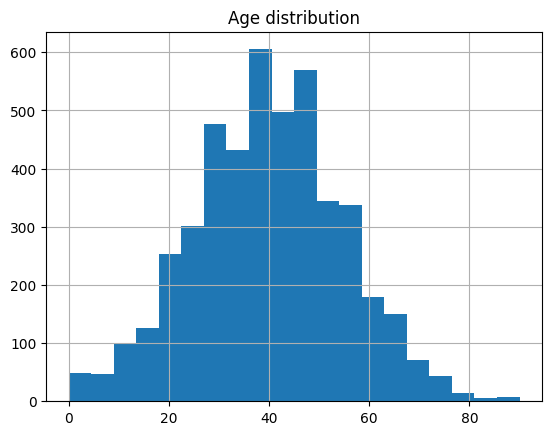

In [9]:
df["age"].hist(bins=20)
plt.title("Age distribution")
plt.show()

In [10]:
median_age = df["age"].median()
df["age"] = df["age"].fillna(median_age)

In [11]:
df["age"].isnull().sum()

np.int64(0)

A histogram was used to analyse missing age values, showing a slight skewed distribution. Median imputation was used as it is less like to be affected by outliers, a final check confirmed no missing values remained. 

In [12]:
median_distance = df["distance_km"].median()
df["distance_km"] = df["distance_km"].fillna(median_distance)

In [13]:
df["distance_km"].isnull().sum()

np.int64(0)

In [14]:
median_travel = df["travel_time_min"].median()
df["travel_time_min"] = df["travel_time_min"].fillna(median_travel)

In [15]:
df["travel_time_min"].isnull().sum()

np.int64(0)

Distance and travel time values also used median imputation.  

In [16]:
mode_email = df["email_reminder"].mode()[0]
df["email_reminder"] = df["email_reminder"].fillna(mode_email)

In [17]:
df["email_reminder"].isnull().sum()

np.int64(0)

In [18]:
mode_employment = df["employment_status"].mode()[0]
df["employment_status"] = df["employment_status"].fillna(mode_employment)

In [19]:
df["employment_status"].isnull().sum()

np.int64(0)

In [20]:
mode_education = df["education_level"].mode()[0]
df["education_level"] = df["education_level"].fillna(mode_education)

In [21]:
df["education_level"].isnull().sum()

np.int64(0)

Mode imputation was used for email_reminder, employment_status, and education_level. These columns are categorical and cannot use mean or median imputation. Using the most common value preserves the dataset.  

In [22]:
df.isnull().sum()

patient_id               0
age                      0
gender                   0
city_type                0
distance_km              0
travel_time_min          0
appointment_day          0
appointment_time_slot    0
department               0
waiting_days             0
previous_appointments    0
previous_no_shows        0
diabetes                 0
hypertension             0
chronic_disease          0
sms_reminder             0
email_reminder           0
num_reminders            0
employment_status        0
education_level          0
insurance_status         0
rainy_day                0
public_holiday           0
no_show                  0
dtype: int64

No missing values remain. 

## Duplicates

In [23]:
df.duplicated().sum()

np.int64(0)

No duplicates. 

## Data types

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             5000 non-null   int64  
 1   age                    5000 non-null   float64
 2   gender                 5000 non-null   object 
 3   city_type              5000 non-null   object 
 4   distance_km            5000 non-null   float64
 5   travel_time_min        5000 non-null   float64
 6   appointment_day        5000 non-null   object 
 7   appointment_time_slot  5000 non-null   object 
 8   department             5000 non-null   object 
 9   waiting_days           5000 non-null   int64  
 10  previous_appointments  5000 non-null   int64  
 11  previous_no_shows      5000 non-null   int64  
 12  diabetes               5000 non-null   int64  
 13  hypertension           5000 non-null   int64  
 14  chronic_disease        5000 non-null   int64  
 15  sms_

The data types for each variable, can change them if another one is more suitable. 

In [25]:
df["email_reminder"] = df["email_reminder"].astype(int)

In [90]:
# Changing from float to category.
categorical_cols = [
    "gender", "city_type", "appointment_day", 
    "appointment_time_slot", "department", 
    "employment_status", "education_level",
    "insurance_status"
]
for col in categorical_cols:
    df[col] = df[col].astype("category")

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   patient_id             5000 non-null   int64   
 1   age                    5000 non-null   float64 
 2   gender                 5000 non-null   category
 3   city_type              5000 non-null   category
 4   distance_km            5000 non-null   float64 
 5   travel_time_min        5000 non-null   float64 
 6   appointment_day        5000 non-null   category
 7   appointment_time_slot  5000 non-null   category
 8   department             5000 non-null   category
 9   waiting_days           5000 non-null   int64   
 10  previous_appointments  5000 non-null   int64   
 11  previous_no_shows      5000 non-null   int64   
 12  diabetes               5000 non-null   int64   
 13  hypertension           5000 non-null   int64   
 14  chronic_disease        5000 non-null   i

This table provides the variables with their new data types.

## Value range

In [28]:
df["age"].describe()

count    5000.000000
mean       39.671000
std        14.331973
min         0.000000
25%        31.000000
50%        40.000000
75%        49.000000
max        90.000000
Name: age, dtype: float64

In [29]:
df[df["distance_km"] < 0]
df[df["travel_time_min"] < 0]
df[df["waiting_days"] < 0]

,patient_id,age,gender,city_type,distance_km,travel_time_min,appointment_day,appointment_time_slot,department,waiting_days,...,chronic_disease,sms_reminder,email_reminder,num_reminders,employment_status,education_level,insurance_status,rainy_day,public_holiday,no_show


Ensures numerical data is realistic. 

## Binary variables

In [91]:
binary_cols = [
    "diabetes", "hypertension", "chronic_disease",
    "sms_reminder", "email_reminder",
    "rainy_day", "public_holiday", "no_show"
]
for col in binary_cols:
    print(col, df[col].unique())
# Print the unique values of the binary variables, should just be 0 or 1.

diabetes [0 1]
hypertension [0 1]
chronic_disease [0 1]
sms_reminder [1 0]
email_reminder [0 1]
rainy_day [1 0]
public_holiday [0 1]
no_show [1 0]


## Categorical values

In [92]:
categorical_cols = [
    "gender", "city_type", "appointment_day",
    "appointment_time_slot", "department", 
    "employment_status", "education_level", "insurance_status"
]
for col in categorical_cols:
    print(col, df[col].astype(str).unique())
# Checking for consistency and correct format.

gender ['Female' 'Male']
city_type ['Suburban' 'Rural' 'Urban']
appointment_day ['Sat' 'Tue' 'Thu' 'Fri' 'Wed' 'Mon']
appointment_time_slot ['Evening' 'Morning' 'Afternoon']
department ['Pediatrics' 'Cardiology' 'General Medicine' 'Dermatology' 'Orthopedics']
employment_status ['Employed' 'Unemployed' 'Student']
education_level ['Higher' 'Secondary' 'Primary']
insurance_status ['Uninsured' 'Insured']


## Outliers

In [32]:
df[["age","distance_km","travel_time_min","waiting_days"]].describe()

,age,distance_km,travel_time_min,waiting_days
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,39.671000,8.293860,41.862300,6.990600
std,14.331973,4.422922,22.285178,2.671917
min,0.000000,0.000000,5.000000,0.000000
25%,31.000000,5.100000,25.300000,5.000000
50%,40.000000,8.100000,40.700000,7.000000
75%,49.000000,11.100000,55.600000,9.000000
max,90.000000,30.400000,128.400000,21.000000


The summary table shows all variables fall in reasonable ranges.  

In [33]:
df.to_csv("cleaned_hospital_dataset.csv", index=False)

# Visualisations

In [34]:
df_clean = pd.read_csv("cleaned_hospital_dataset.csv")

In [35]:
sns.set(style="whitegrid")

In [36]:
# view first rows
df_clean.head()

,patient_id,age,gender,city_type,distance_km,travel_time_min,appointment_day,appointment_time_slot,department,waiting_days,...,chronic_disease,sms_reminder,email_reminder,num_reminders,employment_status,education_level,insurance_status,rainy_day,public_holiday,no_show
0,1,47.0,Female,Suburban,16.5,77.3,Sat,Evening,Pediatrics,8,...,0,1,0,1,Employed,Higher,Uninsured,1,0,1
1,2,37.0,Male,Suburban,6.7,26.9,Tue,Morning,Cardiology,8,...,1,1,0,2,Employed,Secondary,Insured,0,1,0
2,3,49.0,Female,Rural,8.2,46.1,Sat,Evening,General Medicine,3,...,0,1,0,1,Unemployed,Secondary,Insured,0,0,1
3,4,62.0,Female,Urban,2.6,15.2,Thu,Evening,General Medicine,12,...,1,0,1,1,Employed,Secondary,Insured,0,0,0
4,5,36.0,Female,Suburban,4.1,13.8,Fri,Morning,Dermatology,8,...,0,1,0,1,Employed,Secondary,Insured,0,0,1


## 4.1. Age Histogram

The histogram shows a symmetrical distribution centralised around patients between 30-40 years (LabXchange, 2021).  

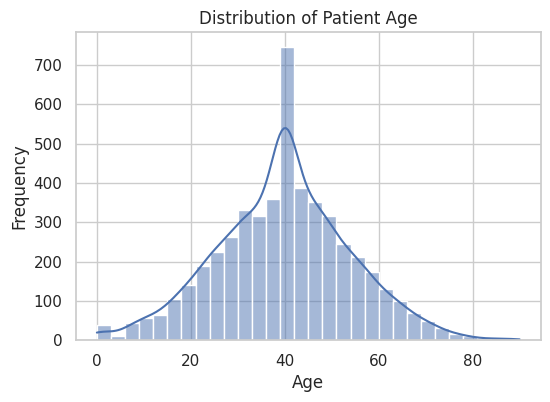

In [37]:
plt.figure(figsize=(6,4))
sns.histplot(df_clean['age'], bins=30, kde=True)
plt.title("Distribution of Patient Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

## 4.2. Distance to hospital histogram

This histogram visualises a positively skewed distribution meaning majority of the patients live near the healthcare service whilst some patients live further away (LabXchange, 2021). 

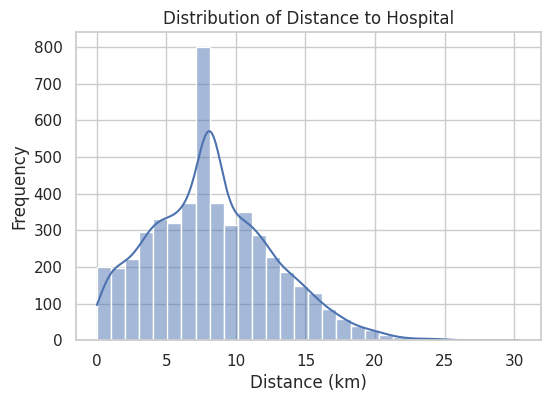

In [38]:
plt.figure(figsize=(6,4))
sns.histplot(df_clean['distance_km'], bins=30, kde=True)
plt.title("Distribution of Distance to Hospital")
plt.xlabel("Distance (km)")
plt.ylabel("Frequency")
plt.show()

## 4.3. Waiting days histogram

This histogram shows a right skewed distribution meaning majority of the patients get appointments in a short waiting time whilst a small group of patients must wait longer for an appointment (LabXchange, 2021). 


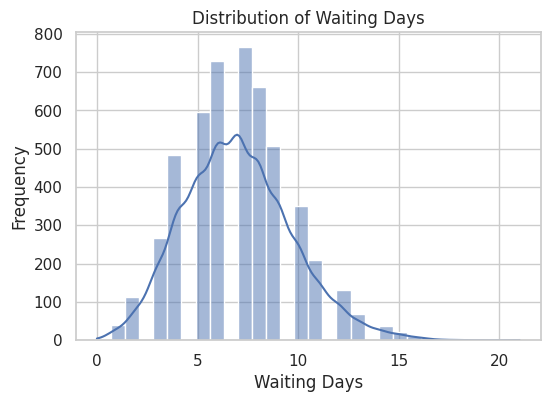

In [39]:
plt.figure(figsize=(6,4))
sns.histplot(df_clean['waiting_days'], bins=30, kde=True)
plt.title("Distribution of Waiting Days")
plt.xlabel("Waiting Days")
plt.ylabel("Frequency")
plt.show()

## 4.4. Previous no show histogram

This histogram shows a highly positively skewed distribution meaning majority of the patients have no missed appointments and a small group of patients have missed appointments (LabXchange, 2021).  

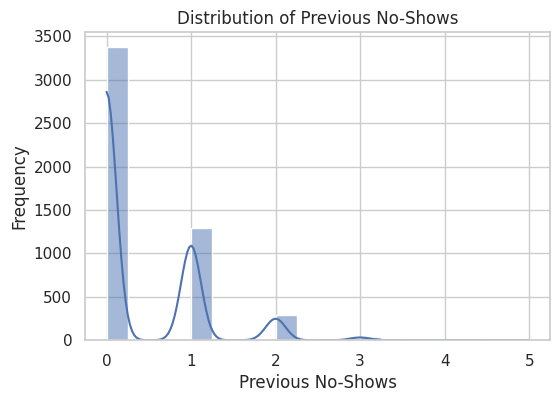

In [40]:
plt.figure(figsize=(6,4))
sns.histplot(df_clean['previous_no_shows'], bins=20, kde=True)
plt.title("Distribution of Previous No-Shows")
plt.xlabel("Previous No-Shows")
plt.ylabel("Frequency")
plt.show()

## 4.5. Age boxplot

Age boxplot represents a moderate variability with a median around Middle Ages and very few outliers showing young or old patients (Yi, 2025).  

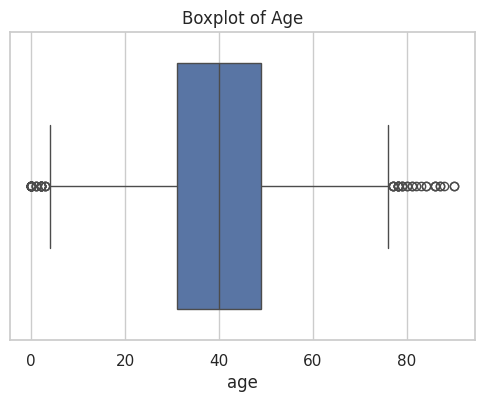

In [41]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df_clean['age'])
plt.title("Boxplot of Age")
plt.show()

## 4.6. Distance boxplot

The boxplot suggests majority of the patients live near the hospital as the middle range values is concentrated at lower distances (Yi, 2025).  

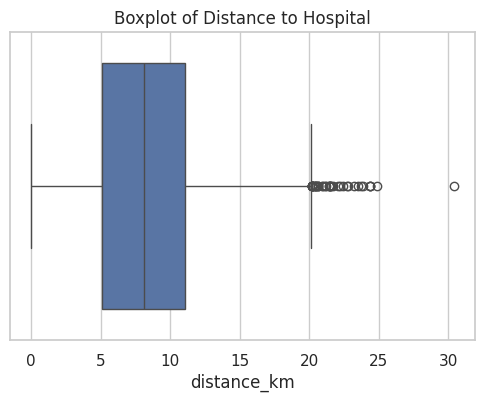

In [42]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df_clean['distance_km'])
plt.title("Boxplot of Distance to Hospital")
plt.show()

## 4.7. Waiting days boxplot

The boxplot shows a significant spread of the existence of extreme outliers indicating inconsistent appointment scheduling in the system (Yi, 2025). 


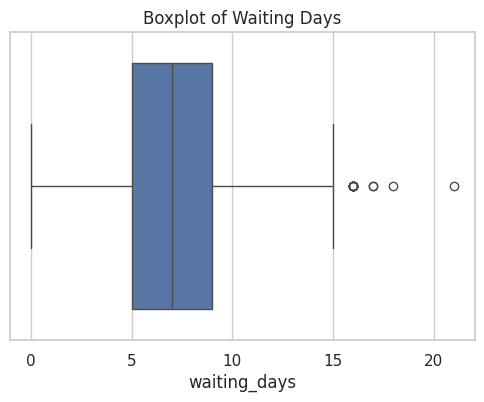

In [43]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df_clean['waiting_days'])
plt.title("Boxplot of Waiting Days")
plt.show()

## 4.8. Previous no shows boxplot

This boxplot visualises a low median with extreme upper outliers showing that no-show attendance is in a small group of patients (Yi, 2025). 

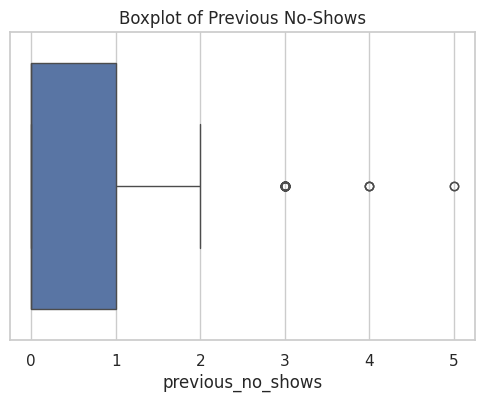

In [44]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df_clean['previous_no_shows'])
plt.title("Boxplot of Previous No-Shows")
plt.show()

# 5. Transforming Data Types


To prepare for machine learning analysis, some variables need to be converted into formats that can be interpreted effectively. The dataset contained text-based categories, date strings and other non-numerical formats. Therefore, these were converted into numerical formats to ensure accurate pattern decisions.  

## 5.1. Encoding Appointment Day

The appointment-day was encoded into number since machine learning model require numerical features where each day from Monday Sunday represents numbers between 0 and 6   

In [45]:
df_clean['appointment_day'].head()

0    Sat
1    Tue
2    Sat
3    Thu
4    Fri
Name: appointment_day, dtype: object

In [46]:
df_clean['appointment_day'].unique()

array(['Sat', 'Tue', 'Thu', 'Fri', 'Wed', 'Mon'], dtype=object)

In [47]:
df_clean['appointment_day'] = df_clean['appointment_day'].astype(str).str.strip()

In [48]:
day_mapping = {
    'Mon':0,
    'Tue':1,
    'Wed':2,
    'Thu':3,
    'Fri':4,
    'Sat':5,
    'Sun':6
}

df_clean['appointment_day'] = df_clean['appointment_day'].map(day_mapping)

In [49]:
df_clean.head()

,patient_id,age,gender,city_type,distance_km,travel_time_min,appointment_day,appointment_time_slot,department,waiting_days,...,chronic_disease,sms_reminder,email_reminder,num_reminders,employment_status,education_level,insurance_status,rainy_day,public_holiday,no_show
0,1,47.0,Female,Suburban,16.5,77.3,5,Evening,Pediatrics,8,...,0,1,0,1,Employed,Higher,Uninsured,1,0,1
1,2,37.0,Male,Suburban,6.7,26.9,1,Morning,Cardiology,8,...,1,1,0,2,Employed,Secondary,Insured,0,1,0
2,3,49.0,Female,Rural,8.2,46.1,5,Evening,General Medicine,3,...,0,1,0,1,Unemployed,Secondary,Insured,0,0,1
3,4,62.0,Female,Urban,2.6,15.2,3,Evening,General Medicine,12,...,1,0,1,1,Employed,Secondary,Insured,0,0,0
4,5,36.0,Female,Suburban,4.1,13.8,4,Morning,Dermatology,8,...,0,1,0,1,Employed,Secondary,Insured,0,0,1


## 5.2. Encoding Categorical Variables

Other categorical texts, such as gender, city type, department, education level, and appointment slots were transformed using one-hot encoding to generate binary columns for each category to allow effective analysis.   

In [50]:
categorical_columns = [
    'gender',
    'city_type',
    'appointment_time_slot',
    'department',
    'employment_status',
    'education_level',
    'insurance_status'
]

df_clean = pd.get_dummies(df_clean, columns=categorical_columns, drop_first=True)

In [51]:
df_clean.head()

,patient_id,age,distance_km,travel_time_min,appointment_day,waiting_days,previous_appointments,previous_no_shows,diabetes,hypertension,...,appointment_time_slot_Morning,department_Dermatology,department_General Medicine,department_Orthopedics,department_Pediatrics,employment_status_Student,employment_status_Unemployed,education_level_Primary,education_level_Secondary,insurance_status_Uninsured
0,1,47.0,16.5,77.3,5,8,2,0,0,0,...,False,False,False,False,True,False,False,False,False,True
1,2,37.0,6.7,26.9,1,8,1,0,1,0,...,True,False,False,False,False,False,False,False,True,False
2,3,49.0,8.2,46.1,5,3,1,0,0,0,...,False,False,True,False,False,False,True,False,True,False
3,4,62.0,2.6,15.2,3,12,1,0,0,1,...,False,False,True,False,False,False,False,False,True,False
4,5,36.0,4.1,13.8,4,8,0,0,0,0,...,True,True,False,False,False,False,False,False,True,False


In [52]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   patient_id                     5000 non-null   int64  
 1   age                            5000 non-null   float64
 2   distance_km                    5000 non-null   float64
 3   travel_time_min                5000 non-null   float64
 4   appointment_day                5000 non-null   int64  
 5   waiting_days                   5000 non-null   int64  
 6   previous_appointments          5000 non-null   int64  
 7   previous_no_shows              5000 non-null   int64  
 8   diabetes                       5000 non-null   int64  
 9   hypertension                   5000 non-null   int64  
 10  chronic_disease                5000 non-null   int64  
 11  sms_reminder                   5000 non-null   int64  
 12  email_reminder                 5000 non-null   i

In [53]:
df_clean.info()

df_clean.isnull().sum()

df_clean.to_csv("processed_hospital_dataset.csv", index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   patient_id                     5000 non-null   int64  
 1   age                            5000 non-null   float64
 2   distance_km                    5000 non-null   float64
 3   travel_time_min                5000 non-null   float64
 4   appointment_day                5000 non-null   int64  
 5   waiting_days                   5000 non-null   int64  
 6   previous_appointments          5000 non-null   int64  
 7   previous_no_shows              5000 non-null   int64  
 8   diabetes                       5000 non-null   int64  
 9   hypertension                   5000 non-null   int64  
 10  chronic_disease                5000 non-null   int64  
 11  sms_reminder                   5000 non-null   int64  
 12  email_reminder                 5000 non-null   i

# 6. Data mining and Business insights

## 6.1 Decision tree model

This model was chosen for predicting no-show behaviour for hospital appointments because of the many methodological and practical benefits it presents. First benefit is the model can identify non-linear relationships between variables (Inside Learning Machines, 2023). Patients' attendance is impacted by many different factors like waiting time, distance to location and past no-show record.  

This model needs minimal data preparation in comparison to other machine learning methods (Inside Learning Machines, 2023). It analyses each feature separately in the splitting phase meaning scaling and normalization is not required.   

It can deal with missing values and categorical values meaning additional preprocessing is not needed for dealing with missing and categorical values (Inside Learning Machines, 2023). 

Decision Tree results: No show 
Accuracy- 52%  
Precision-0.52  
Recall- 0.53  
F1= 0.52  

The model showed the potential to identify the main factors impacting patient no-show behaviour. Accuracy meaning the performance evaluation metric suggested that the model can reliably categorize if a patient will attend their appointment or not.  

Interpretation of the tree structure showed that factors like distance to hospital, previous no-shows, waiting time before appointment have the most impact on patient show or no-show. Patients that tend to miss appointments often are likely to miss future appointments indicating that behaviour affects attendance in appointments.  

Waiting longer for appointment booking and dates increased the likelihood of not showing. This assumes that patients are likely to forget their appointments or give up when there is a longer waiting period. Patients that live far from the hospital location are likely to not show up compared to those who live closer.  These patterns show that the following appointment schedule is impacted by operational and behavioural indicators.  

Business intelligence:  

The results from interpretation of the model gives beneficial insights for hospital administration teams who are looking to improve attendance level and make effective use of resources.  

Hospitals should integrate targeted intervention strategies for high-risk patients looking at no-show as the main predictor. This means patients that do not show could be given regular reminders, private communication could be used, or policies could be put in place for the consequence of not attending appointments.  

Impact of waiting times could be reduced by decreasing scheduling delays to increase attendance level. An effective scheduling system or overbooking methodology could be implemented to reduce appointments that have not been used and to overall improve service. 

In [54]:
df_processed = pd.read_csv('processed_hospital_dataset.csv')

In [55]:
# Display columns to confirm structure
print("Columns:", df_processed.columns)

Columns: Index(['patient_id', 'age', 'distance_km', 'travel_time_min',
       'appointment_day', 'waiting_days', 'previous_appointments',
       'previous_no_shows', 'diabetes', 'hypertension', 'chronic_disease',
       'sms_reminder', 'email_reminder', 'num_reminders', 'rainy_day',
       'public_holiday', 'no_show', 'gender_Male', 'city_type_Suburban',
       'city_type_Urban', 'appointment_time_slot_Evening',
       'appointment_time_slot_Morning', 'department_Dermatology',
       'department_General Medicine', 'department_Orthopedics',
       'department_Pediatrics', 'employment_status_Student',
       'employment_status_Unemployed', 'education_level_Primary',
       'education_level_Secondary', 'insurance_status_Uninsured'],
      dtype='object')


In [56]:
TARGET_COLUMN = 'no_show'

# Features & target split
X = df_processed.drop(TARGET_COLUMN, axis=1)
y = df_processed[TARGET_COLUMN]

In [57]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [58]:
# Model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [59]:
# Predictions
y_pred = model.predict(X_test)

In [60]:
# Evaluation
print("\nModel Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Model Evaluation:
Accuracy: 0.519

Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.51      0.51       500
           1       0.52      0.53      0.52       500

    accuracy                           0.52      1000
   macro avg       0.52      0.52      0.52      1000
weighted avg       0.52      0.52      0.52      1000



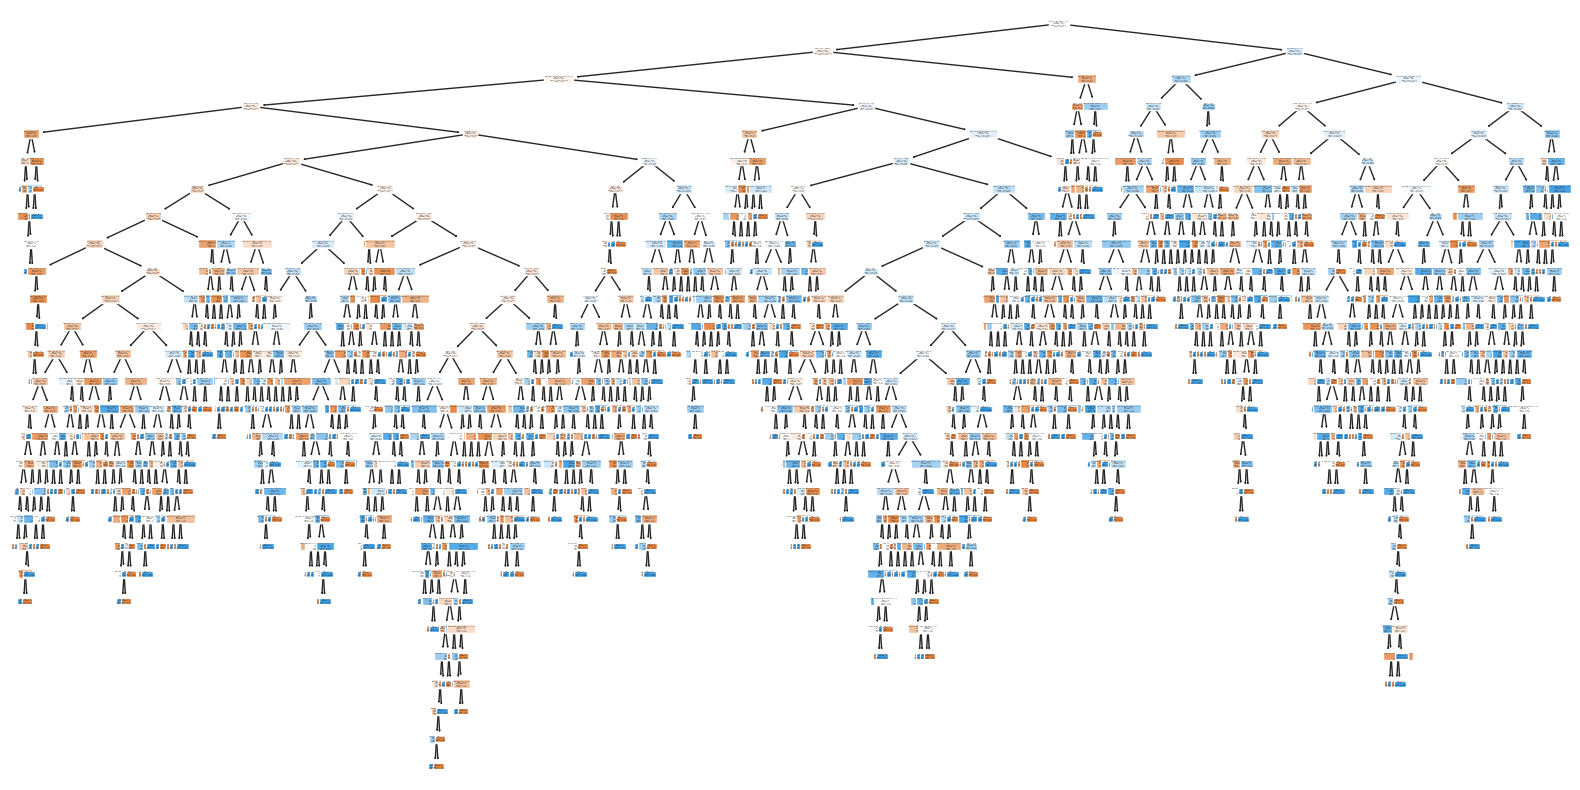

In [61]:
plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Show', 'No Show'],
    filled=True
)

plt.show()

## 6.2. Logistic  Regression

This section uses a machine learning approach to predict patient no-shows by using Logistic Regression. The objective of this technique is to identify patterns in patient behaviour, translating them into actionable business insights



### 6.2.1. Justification Analysis
 Logistic regression is suitable because the variable “no-show" is binary, which enables the model to estimate the probability that a patient misses their appointment, therefore making it more effective than a linear regression model, which is not designed for categorical outcomes (Buhl,2023). A key advantage of this model is its interpretability, where each coefficient shows the magnitude and direction of its effect on the probability of a no-show (Jain,2023). This helps hospitals understand why a patient misses their appointments and assess whether factors like SMS reminders, waiting time affect attendance.  

The model is also suitable for a structured dataset and is less prone to overfitting compared to other algorithms like Random Forest (Stumpfe and Shongwe,2026). However, logistic regression assumes a linear relationship between independent and dependent variables, which may oversimplify real-world behaviours (Babbar,2023).  It is also sensitive to multicollinearity, reducing the interpretability of features that are highly correlated (Marco,204).  

Other models like Random Forests, SVMs and Gradient boosting could capture non-linear but lack interpretability, making it less suitable for this model (Flachaire et al.,2023). In healthcare setting, these models limit transparency which variable can be useful to predict the outcome and therefore undermine trust and make it more difficult for hospitals to justify decisions 

In [62]:
df_processed.head()

,patient_id,age,distance_km,travel_time_min,appointment_day,waiting_days,previous_appointments,previous_no_shows,diabetes,hypertension,...,appointment_time_slot_Morning,department_Dermatology,department_General Medicine,department_Orthopedics,department_Pediatrics,employment_status_Student,employment_status_Unemployed,education_level_Primary,education_level_Secondary,insurance_status_Uninsured
0,1,47.0,16.5,77.3,5,8,2,0,0,0,...,False,False,False,False,True,False,False,False,False,True
1,2,37.0,6.7,26.9,1,8,1,0,1,0,...,True,False,False,False,False,False,False,False,True,False
2,3,49.0,8.2,46.1,5,3,1,0,0,0,...,False,False,True,False,False,False,True,False,True,False
3,4,62.0,2.6,15.2,3,12,1,0,0,1,...,False,False,True,False,False,False,False,False,True,False
4,5,36.0,4.1,13.8,4,8,0,0,0,0,...,True,True,False,False,False,False,False,False,True,False


In [63]:
df_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   patient_id                     5000 non-null   int64  
 1   age                            5000 non-null   float64
 2   distance_km                    5000 non-null   float64
 3   travel_time_min                5000 non-null   float64
 4   appointment_day                5000 non-null   int64  
 5   waiting_days                   5000 non-null   int64  
 6   previous_appointments          5000 non-null   int64  
 7   previous_no_shows              5000 non-null   int64  
 8   diabetes                       5000 non-null   int64  
 9   hypertension                   5000 non-null   int64  
 10  chronic_disease                5000 non-null   int64  
 11  sms_reminder                   5000 non-null   int64  
 12  email_reminder                 5000 non-null   i

In [64]:
y = df_processed['no_show']
X = df_processed.drop('no_show', axis=1)

In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [66]:
# Scale the data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model again with more iterations
model = LogisticRegression(max_iter=2000, class_weight='balanced')
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

The dataset was separated into x and y value Numerical was standardised using StandScaler to ensure equal weighting, and the model was trained with iteration of 2000 to ensure convergence  

False Negatives are particularly critical as they represent missed opportunities to prevent no-shows, leading to inefficiencies in healthcare   

In [67]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [68]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.512


In [69]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.51      0.55      0.53       500
           1       0.51      0.48      0.49       500

    accuracy                           0.51      1000
   macro avg       0.51      0.51      0.51      1000
weighted avg       0.51      0.51      0.51      1000



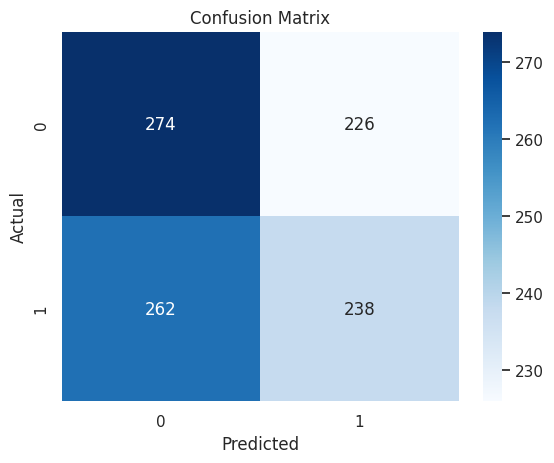

In [70]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# The ROC curve assesses the model to differentiate between classes at various thresholds. A higher AUC indicates better predicative capability which is condensed into a single value


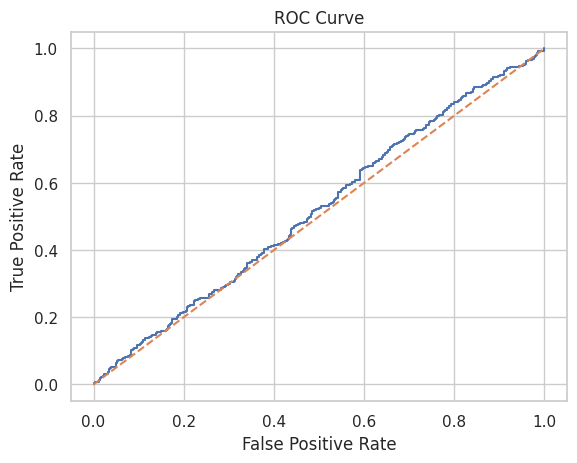

AUC Score: 0.519468


In [71]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

print("AUC Score:", roc_auc_score(y_test, y_prob))

In [72]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

coefficients = coefficients.sort_values(by='Coefficient', ascending=False)

coefficients

,Feature,Coefficient
7,previous_no_shows,0.157403
19,appointment_time_slot_Evening,0.105010
13,num_reminders,0.074861
28,education_level_Secondary,0.070856
17,city_type_Suburban,0.063952
14,rainy_day,0.062835
6,previous_appointments,0.041022
3,travel_time_min,0.038759
18,city_type_Urban,0.033261
8,diabetes,0.031927


<Axes: >

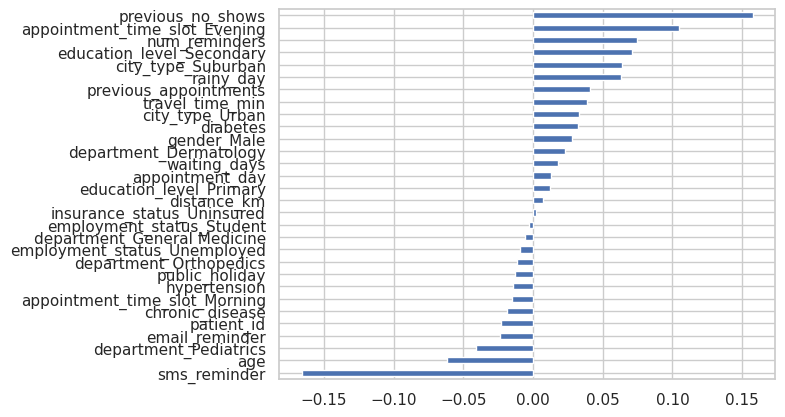

In [73]:
coefficients = pd.Series(model.coef_[0], index=X.columns)
coefficients.sort_values().plot(kind='barh')

  Positive coefficients increase the probability of missing an appointment. Negative coefficient decreases it   

### 6.2.6. Interpretation of logistic Regression Results

The model achieved 51-52% accuracy, with precision and recall of 0.51-0.53 which indicates the model struggled to assess high-risk attendance. The AUC score of 0.519 suggest that the ROC could not effectively separate those who attends and does not. ROC model is less suitable as it produced probabilities with minimal separation which results in a curve close to the diagonal.   

The coefficient provided a useful result where positive coefficients, like patient's locations, and previous no-shows have a higher probability of missing appointments. Whereas a negative coefficient (SMS) suggests improvement in attending.   

The poor performance may suggest that the reason behind a no-show is influenced by other factors, such as personal circumstances or transport issues  

Actionable Business Intelligence:  

Patients with a history of missing of missed appointments should be flagged and monitored - e.g., implementing early warning triggers in booking systems to allow hospitals to send personalised reminders to patients 

Implement multi-stage reminders – e.g have one message at booking, one 48 hours before and a two-way confirmation on the day 

Improve in Data collection – e.g. travel difficulties, parking limitations, and public transport availability.  

Qualitative approach – e.g. surveys to capture reasons why for missed appointments, which can give insight into more targeted interventions in the future 

## Clustering


### Justification:

To understand why patients are missing their appointments, it is important to learn the factors that contribute. Clustering is appropriate for this database as it classifies data points based on similarities and patterns without needing predefined labels, with the goal being exploratory insight (IBM, n.d.). It has multiple advantages (CareerFoundry, 2023): 
- Identifying patterns: Reveals patient groups with different no-show behaviours. 
- Reducing complexity: Grouping reduces complexity in large datasets. 
- Improving visuals: Cluster visualisations help communicate findings. 

### K-Means Clustering  

K-means is appropriate for this database as it uncovers patient groups based on their behavioural, demographic, and contextual features. It is efficient for large databases, easily scaling 40+ features (Google, n.d.). Widely used in healthcare for patient segmentation, resource allocation, and predictive modelling (FlyRank, 2025). Other alternatives like hierarchical clustering or DBSCAN would struggle to analyse the database efficiently and effectively, as it contains 5000 rows and various features. K-means offers a scalable approach making it the suitable method. 

Limitations include needing to manually choose K, which can lead to inaccurate results, and sensitivity to outliers, resulting in less reliable clusters (Google, n.d.; Medium, 2023). 

### Clustering features 

Clustering applies its own one-hot encoding to the cleaned database, as multicollinearity is less critical than in regression and removing categories is inappropriate.  


In [74]:
# Loading the cleaned database 
df_clean = pd.read_csv("cleaned_hospital_dataset.csv")
df_clean.head()

,patient_id,age,gender,city_type,distance_km,travel_time_min,appointment_day,appointment_time_slot,department,waiting_days,...,chronic_disease,sms_reminder,email_reminder,num_reminders,employment_status,education_level,insurance_status,rainy_day,public_holiday,no_show
0,1,47.0,Female,Suburban,16.5,77.3,Sat,Evening,Pediatrics,8,...,0,1,0,1,Employed,Higher,Uninsured,1,0,1
1,2,37.0,Male,Suburban,6.7,26.9,Tue,Morning,Cardiology,8,...,1,1,0,2,Employed,Secondary,Insured,0,1,0
2,3,49.0,Female,Rural,8.2,46.1,Sat,Evening,General Medicine,3,...,0,1,0,1,Unemployed,Secondary,Insured,0,0,1
3,4,62.0,Female,Urban,2.6,15.2,Thu,Evening,General Medicine,12,...,1,0,1,1,Employed,Secondary,Insured,0,0,0
4,5,36.0,Female,Suburban,4.1,13.8,Fri,Morning,Dermatology,8,...,0,1,0,1,Employed,Secondary,Insured,0,0,1


In [95]:
# Features for clustering, all except patient ID and no-show rate.
features = [
    'age', 'gender', 'city_type', 'distance_km', 'travel_time_min', 'appointment_day', 
    'appointment_time_slot', 'department', 'waiting_days', 'previous_appointments', 'previous_no_shows', 
    'diabetes', 'hypertension', 'chronic_disease', 'sms_reminder', 'email_reminder', 'num_reminders', 
    'employment_status', 'education_level', 'insurance_status', 'rainy_day', 'public_holiday'
]

df_features = df_clean[features]

df_features.head()


,age,gender,city_type,distance_km,travel_time_min,appointment_day,appointment_time_slot,department,waiting_days,previous_appointments,...,hypertension,chronic_disease,sms_reminder,email_reminder,num_reminders,employment_status,education_level,insurance_status,rainy_day,public_holiday
0,47.0,Female,Suburban,16.5,77.3,Sat,Evening,Pediatrics,8,2,...,0,0,1,0,1,Employed,Higher,Uninsured,1,0
1,37.0,Male,Suburban,6.7,26.9,Tue,Morning,Cardiology,8,1,...,0,1,1,0,2,Employed,Secondary,Insured,0,1
2,49.0,Female,Rural,8.2,46.1,Sat,Evening,General Medicine,3,1,...,0,0,1,0,1,Unemployed,Secondary,Insured,0,0
3,62.0,Female,Urban,2.6,15.2,Thu,Evening,General Medicine,12,1,...,1,1,0,1,1,Employed,Secondary,Insured,0,0
4,36.0,Female,Suburban,4.1,13.8,Fri,Morning,Dermatology,8,0,...,0,0,1,0,1,Employed,Secondary,Insured,0,0


In [76]:
list(categorical_cols)

['gender',
 'city_type',
 'appointment_day',
 'appointment_time_slot',
 'department',
 'employment_status',
 'education_level',
 'insurance_status']

In [77]:
# Ordering the weekdays
weekday_order = CategoricalDtype(
    categories=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat"],
    ordered=True
)
df_clean["appointment_day"] = (
    df_clean["appointment_day"]
        .astype("string")
        .str.strip()
        .astype(weekday_order)
)

In [78]:
# Only include columns that exisit in df.columns
categorical_cols = [c for c in categorical_cols if c in df.columns]
df_features = pd.get_dummies(df_features, columns=categorical_cols, drop_first=False)

In [79]:
df_features.head()

,age,distance_km,travel_time_min,waiting_days,previous_appointments,previous_no_shows,diabetes,hypertension,chronic_disease,sms_reminder,...,department_Orthopedics,department_Pediatrics,employment_status_Employed,employment_status_Student,employment_status_Unemployed,education_level_Higher,education_level_Primary,education_level_Secondary,insurance_status_Insured,insurance_status_Uninsured
0,47.0,16.5,77.3,8,2,0,0,0,0,1,...,False,True,True,False,False,True,False,False,False,True
1,37.0,6.7,26.9,8,1,0,1,0,1,1,...,False,False,True,False,False,False,False,True,True,False
2,49.0,8.2,46.1,3,1,0,0,0,0,1,...,False,False,False,False,True,False,False,True,True,False
3,62.0,2.6,15.2,12,1,0,0,1,1,0,...,False,False,True,False,False,False,False,True,True,False
4,36.0,4.1,13.8,8,0,0,0,0,0,1,...,False,False,True,False,False,False,False,True,True,False


In [93]:
# Turning tru/false boolean into integers (0/1).
bool_cols = df_features.select_dtypes(include='bool').columns
df_features[bool_cols] = df_features[bool_cols].astype(int)

In [94]:
# Scaling data to be on similar levels
to_scale = ["age", "distance_km", "travel_time_min", "waiting_days", "previous_appointments", 
            "previous_no_shows", "num_reminders"
           ]
to_scale = [c for c in to_scale if c in df_features.columns]

In [82]:
scaler = StandardScaler(with_mean=False)
X_part = scaler.fit_transform(df_features[to_scale])

In [83]:
df_scaled = df_features.copy()
df_scaled[to_scale] = X_part
# Save the new dataset specific for clustering
df_scaled.to_csv("cluster_hospital_dataset.csv", index=False)

In [84]:
# Inputting the cluster dataset to start clustering
df_cluster = pd.read_csv("cluster_hospital_dataset.csv")

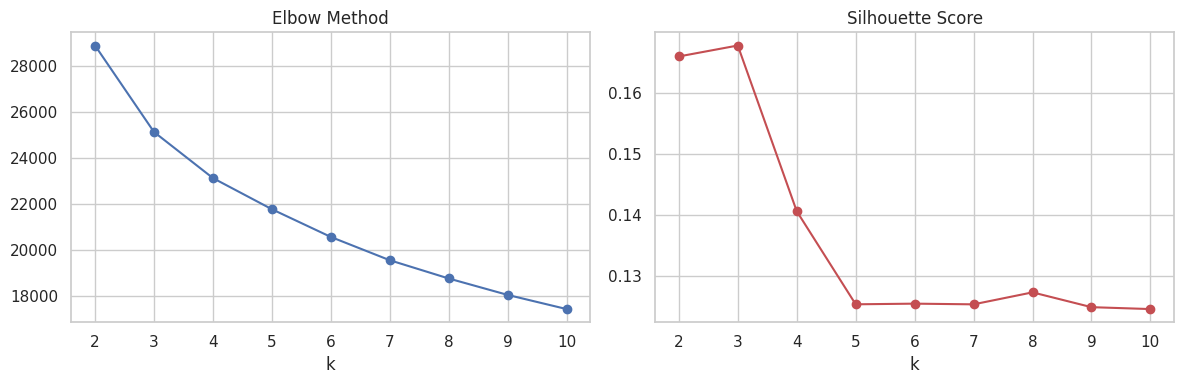

In [85]:
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_part)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_part, labels))

# Plot the elbow method
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_range), inertias, 'bo-')
axes[0].set_title('Elbow Method'); axes[0].set_xlabel('k')

# Plot the silhouette score
axes[1].plot(list(K_range), silhouettes, 'ro-')
axes[1].set_title('Silhouette Score'); axes[1].set_xlabel('k')

# Display plots
plt.tight_layout(); plt.savefig('elbow_silhouette.png', dpi=150)
plt.show()

Both the Elbow method and Silhouette score suggests that K= 3, to show well-structured clusters while avoiding over-segmentation.  

In [86]:
# Fit K-means with k=3
km = KMeans(n_clusters=3, random_state=42, n_init=10)
X['cluster'] = km.fit_predict(X_part)

# Cluster sizes
print("Cluster sizes:")
print(X['cluster'].value_counts().sort_index())

# The mean of each feature per cluster
print("\nCluster profiles:")
profile = X.groupby('cluster').mean().round(2)

# Features as rows, clusters as columns
print(profile.T)  

Cluster sizes:
cluster
0    2302
1    1628
2    1070
Name: count, dtype: int64

Cluster profiles:
cluster                              0        1        2
patient_id                     2488.14  2533.77  2476.46
age                              39.75    39.68    39.49
distance_km                       5.31    12.78     7.88
travel_time_min                  26.65    64.59    40.01
appointment_day                   2.53     2.52     2.50
waiting_days                      6.87     7.17     6.97
previous_appointments             1.53     1.66     3.57
previous_no_shows                 0.13     0.19     1.31
diabetes                          0.19     0.19     0.18
hypertension                      0.29     0.29     0.28
chronic_disease                   0.47     0.47     0.49
sms_reminder                      0.73     0.68     0.70
email_reminder                    0.38     0.34     0.38
num_reminders                     1.45     1.34     1.41
rainy_day                         0.21     0.21

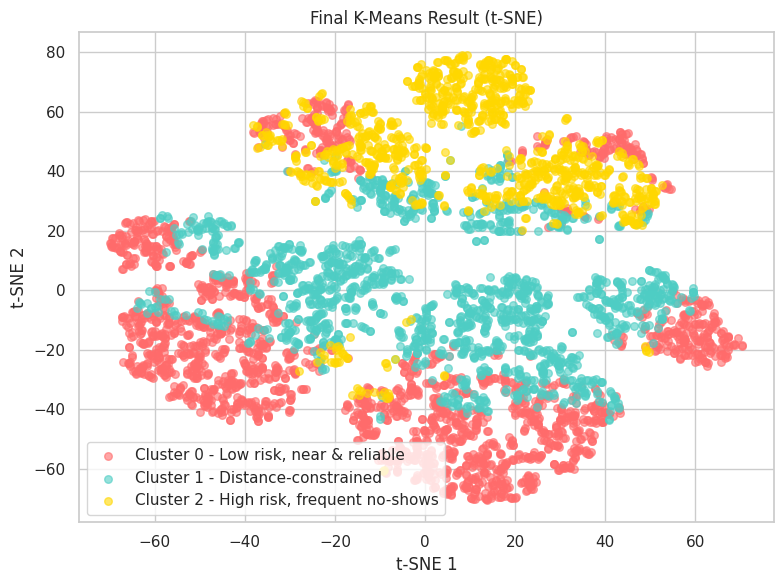

In [87]:
# Reduce to 2D with t-SNE (better at separating clusters visually)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_2d = tsne.fit_transform(X_part)

# Plot
plt.figure(figsize=(8, 6))
colors = ['#FF6B6B', '#4ECDC4', '#FFD700']
labels = ['Cluster 0 - Low risk, near & reliable', 'Cluster 1 - Distance-constrained', 'Cluster 2 - High risk, frequent no-shows']

for i in range(3):
    mask = X['cluster'].values == i
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                c=colors[i], label=labels[i], alpha=0.6, s=30)

plt.title('Final K-Means Result (t-SNE)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.legend()
plt.tight_layout()
plt.show()

In [88]:
df['cluster'] = X['cluster']

In [89]:
# Calculate the count and mean of no show rate %
validation = df.groupby('cluster')['no_show'].agg(['count','mean'])

validation['mean'] = validation['mean'].round(3)

validation['percent_no_show'] = (validation['mean']*100).round(1)
print(validation)

         count   mean  percent_no_show
cluster                               
0         2302  0.469             46.9
1         1628  0.494             49.4
2         1070  0.576             57.6


### Results Interpretations:
K-means identified three meaningful clusters; the t-SNE plot confirm the structured patterns. 

Cluster 0 (near and reliable): Shortest travel, lowest previous no-shows, and recieves the most reminders. Largest segment (2302 patients) and lowest no-show rate (46.9%). Absences are likely one-time occurrences.  

Cluster 1 (logistical barriers): Longest travel, longer waiting times, and fewest reminders. Have moderate no-show rate (49.4%). Absences are likely due to access and reminder barriers. 

Cluster 2 (high-risk and frequent): Highest no-show rate (57.6%) despite moderate logistics. Absences are likely caused by behaviour factors. 

Patient demographics and clinical variables had little impact. Attendance is mainly influenced by travel, history, and reminders. Clusters were validated by comparing them to the actual no-show rates.  

### Actionable business intelligence  

Cluster 0: Maintain standard reminder routine, minimal intervention needed. 

Cluster 1: Increase patient reminders and reduce travel barriers (e.g., transport support, online options.) 

Cluster 2: Implement personalised interventions, including follow-up calls or multi-set reminders.  

Clustering results provide the hospital with targeted strategies to reduce no-show appointment rates.  


# Evaluation

## Business
Hospital appointment no-shows impose a major financial burden on healthcare services. In the United Kingdom, NHS England reported that nearly 7.5 million outpatient appointments were missed in 2021/2022 alone. This highlights the necessity of developing effective business intelligence tools to address this issue (NHS England, 2023). 

The Decision Tree and a Logistic Regression classifier, which are the two predictive models developed in this project, were trained on a 5,000-patient dataset to predict if a patient would miss their appointment. Both models achieved accuracy scores of approximately 51–52%, which is only slightly better than a random baseline of 50%. From a business perspective, this level of predictive performance only provides a limited immediate return on investment. Deploying a model with such low accuracy scores in a real hospital setting could lead to a large number of patients being misclassified. This could lead to ineffective, poorly targeted interventions and potentially wasted resources on reminder systems or outreach programmes. 

However, the clustering analysis identified three meaningful patient segments: low-risk, distance-constrained, and high-risk frequent non-attenders. These identified segments provide greater potential for actionable business insights. Implementing targeted strategies for high-risk clusters, such as enhanced email and SMS notification campaigns or more flexible rescheduling options for distance-constrained patients who can’t make it in person, could effectively reduce no-show rates in a cost-efficient way without needing high model accuracy. If there were even a slight decrease of 5-10% in no-show rates across the dataset, the resulting improvements in resource utilisation and patient flow would deliver a significant return on investment for hospital administrators. 

In conclusion, while the predictive models alone do not yet justify large-scale operational deployment, the combined insights gained from clustering and feature analysis can be used to make targeted, data-driven business strategies that can improve appointment attendance and minimize financial losses. 

## Technical 

The impact of the technical part of the project was evaluated over the whole data mining process. When cleaning the dataset, it needed analytical reliability as missing values were dealt with, repeated records were deleted and data types were verified to ensure there is consistency across variables. Outliers were identified using boxplot methods which led to extreme observations being identified that could impact model learning.  

Exploratory data analysis helped to identify behavioural insights linked to attendance rate for hospital appointments. Histograms and boxplots were used to interpret distribution of important factors like age, waiting time, distance and no-show record. This helped to identify possible predictors of no-show for appointment and what modelling technique had to be applied.  

Random forest could have been applied to improve validation by improving predictions and generalisation performance. It has been indicated that no-show for appointments could be due to psychological, social or contextual factors that have not been explored in the dataset.  

The project has shown a great usage of technical implementation of business intelligence ad data mini application. Even though there were drawbacks in prediction level the methods and techniques created valuable patterns to support hospital appointment attendance to make informed decisions.  

## Ethical, Security, and Privacy
The logistic regression model used to predict a “no-show” appointment raises important ethical and fairness issues due to the data types used. Variables such as age, gender, Neighbourhood type e.g. suburban or urban and SMS_recived are the reason why people miss their appointments. However, these variables may not fully be the reason on why they missed their appointment.  

For instance, patients from certain neighbourhood may be predicted as more likely to miss appointments, but this could be due to external factors such as transport, work schedules, or access to healthcare rather than a personal choice. Furthermore, patients who did not receive SMS reminders may be unfairly labelled as who misses their appointment, even though this could be due lack of phone access or system issues. As a result, the model could be treating some groups unfairly especially for those who are already at high risk of missing appointments. 

Although the confusion matrix and ROC curve indicate that the model works quite well, they do not show whether predictions are fair across different groups. To reduce risks, the model should be tested across different demographics, and features should be reviewed carefully. 

This project raises several privacy and security concerns due to the sensitivity of the health-related attributes. While the data does not include names or addresses, it has several other factors, such as age, travel distance, and chronic disease, that when put together could be used to identify a patient. To comply with GDPR, the data should only be used for its purpose, stored securely, and deleted when no longer needed. If deployed, the predictive models and cluster could unintentionally revel patterns about vulnerable groups, therefore access to raw data and model results should be limited to authorised staff to reduce privacy risks. From a security viewpoint, the models may be susceptible to risks including model extraction, data poisoning, and unauthorised access. The hospital should implement strict access controls, encryption, and monitor logging to mitigate these risks.  